# Exploratory Data Analysis (EDA) of Zomato Restaurant Dataset

## Student Information
- Name: ايات علاء اياد
- Course: Big Data Analysis

## Dataset Description
This dataset contains information about restaurants listed on Zomato, including ratings, votes, cuisines, cities, online delivery services, table booking availability, and restaurant costs.

## Research Questions
1. Which cities have the highest number of restaurants?
2. Does online delivery affect restaurant ratings?
3. Does table booking affect restaurant ratings?
4. Is there a relationship between votes and ratings?
5. Do expensive restaurants receive higher ratings?
6. Which cuisines are the most common?


## B. Load and Inspect the Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Zomato Restaurant Dataset.csv")

df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
# Dataset Shape
df.shape

(9551, 21)

In [4]:
# Column Names
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [5]:
# Data Types and General Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [6]:
# Statistical Summary
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


### Explanation
The dataset contains numerical and categorical variables describing restaurant characteristics.


## C. Check and Prepare the Data

In [7]:
# Missing Values
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

### Explanation
Check which columns contain missing values before cleaning.


In [8]:
# Handle Missing Values
df["Cuisines"] = df["Cuisines"].fillna("Unknown")

In [9]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

### Explanation
If duplicate rows exist, they should be removed after verification.


In [11]:
# Check Unique Values in Each Column
for col in df.columns:
    print(col, ':', df[col].nunique())


Restaurant ID : 9551
Restaurant Name : 7446
Country Code : 15
City : 141
Address : 8918
Locality : 1208
Locality Verbose : 1265
Longitude : 8120
Latitude : 8677
Cuisines : 1826
Average Cost for two : 140
Currency : 12
Has Table booking : 2
Has Online delivery : 2
Is delivering now : 2
Switch to order menu : 1
Price range : 4
Aggregate rating : 33
Rating color : 6
Rating text : 6
Votes : 1012


In [12]:
# Remove Unnecessary Column
if "Switch to order menu" in df.columns:
    df.drop("Switch to order menu", axis=1, inplace=True)


## D. Describe and Visualize the Data

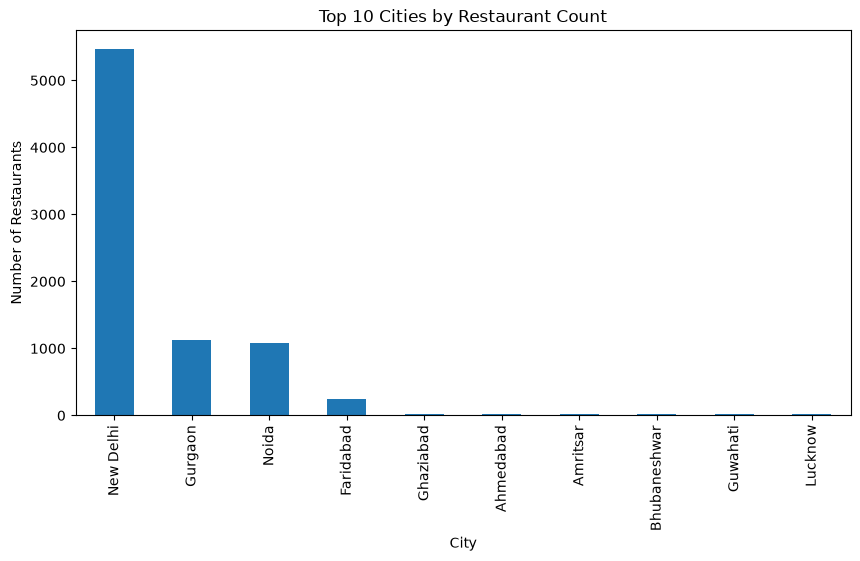

In [44]:
# Top Cities
plt.figure(figsize=(10,5))
df["City"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.show()




### Interpretation

The bar chart shows that restaurant distribution is not uniform across cities. A small number of cities contain a large proportion of the restaurants in the dataset, indicating that restaurant activity is concentrated in specific urban areas. This may reflect differences in population size, economic activity, and customer demand among cities.

### Interpretation
This chart shows the cities with the highest number of restaurants.

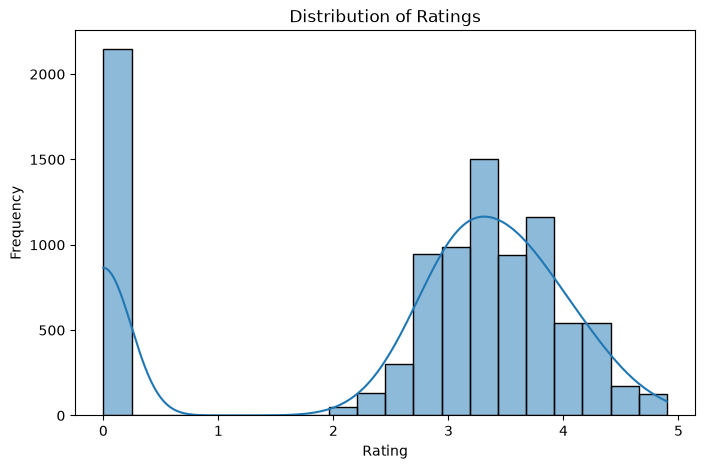

In [43]:
# Rating Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Aggregate rating"], bins=20, kde=True)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()


The histogram indicates that most restaurants receive medium to high ratings, while very low ratings are relatively uncommon. This suggests that the majority of restaurants in the dataset maintain acceptable service quality and customer satisfaction levels.

### Interpretation
This chart shows how ratings are distributed among restaurants.

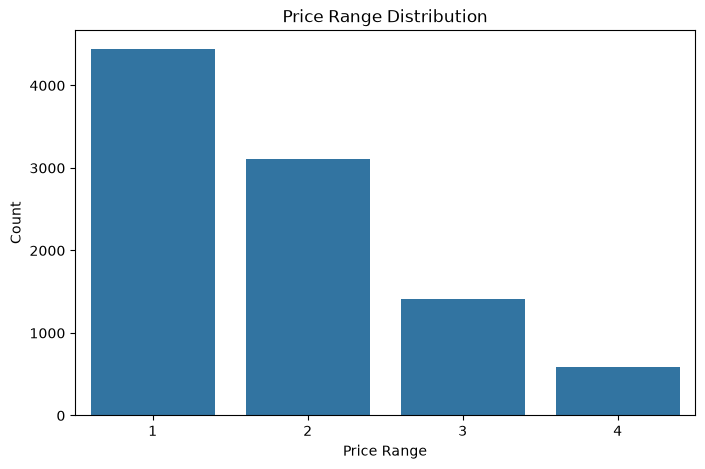

In [9]:
# Price Range Distribution
plt.figure(figsize=(8,5))
sns.countplot(x="Price range", data=df)
plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Count")
plt.show()


The results show that certain price categories are more common than others. Most restaurants belong to the lower and medium price ranges, suggesting that affordable dining options are more widely available than expensive restaurants.

### Interpretation
Shows the most common price ranges.

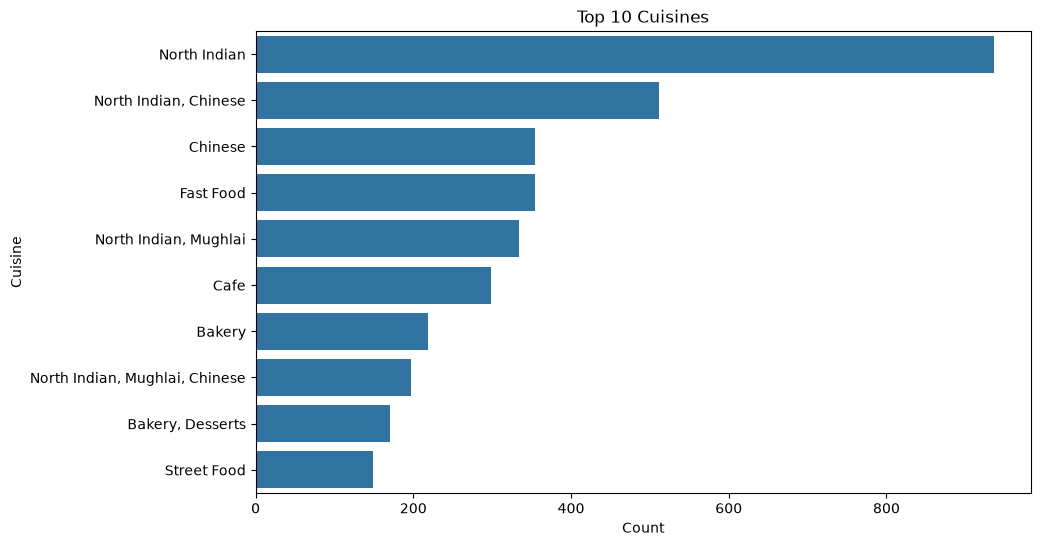

In [45]:
# Top Cuisines
top_cuisines = df["Cuisines"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 10 Cuisines")
plt.xlabel("Count")
plt.ylabel("Cuisine")
plt.show()


The cuisine analysis reveals that some cuisine types appear much more frequently than others. This indicates customer preference for particular food categories and reflects the dominant food culture represented in the dataset.


### Interpretation
Shows the most popular cuisines in the dataset.

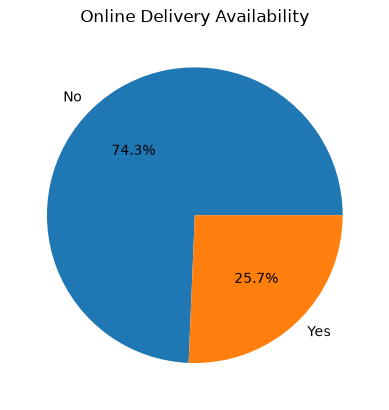

In [46]:
# Online Delivery Availability
df["Has Online delivery"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Online Delivery Availability")
plt.ylabel("")
plt.show()


The pie chart demonstrates the proportion of restaurants that offer online delivery services. The results indicate that online delivery is available in a considerable number of restaurants, reflecting the growing importance of digital food ordering platforms.

### Interpretation
Shows the percentage of restaurants that offer online delivery.

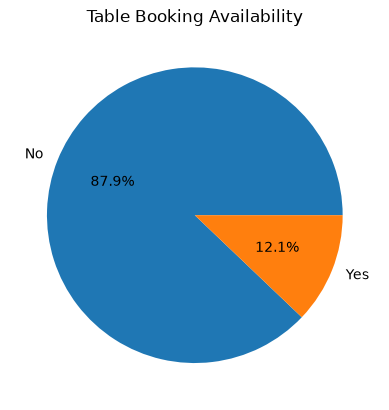

In [47]:
# Table Booking Availability
df["Has Table booking"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Table Booking Availability")
plt.ylabel("")
plt.show()


The analysis shows that only a portion of restaurants provide table booking services. This may be because table reservations are more common among formal dining establishments than casual restaurants.

### Interpretation
Shows the percentage of restaurants that provide table booking.

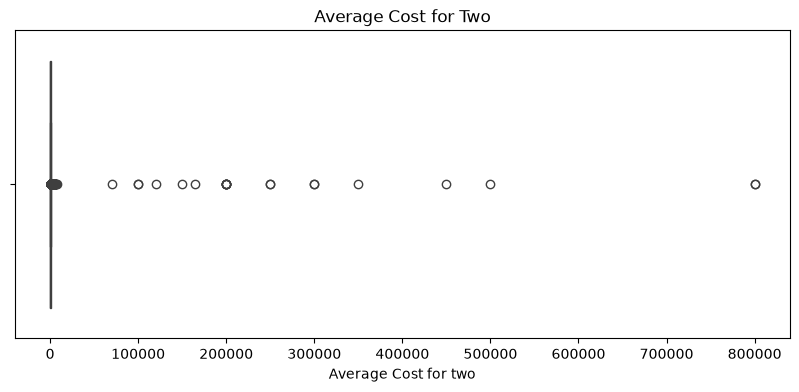

In [48]:
# Cost Outliers
plt.figure(figsize=(10,4))
sns.boxplot(x=df["Average Cost for two"])
plt.title("Average Cost for Two")
plt.show()


The box plot identifies several restaurants with unusually high average costs. These observations can be considered outliers and may represent luxury or premium dining establishments that differ significantly from the majority of restaurants.


### Interpretation
Boxplot helps identify extreme cost values and outliers.

## E. Explore Relationships

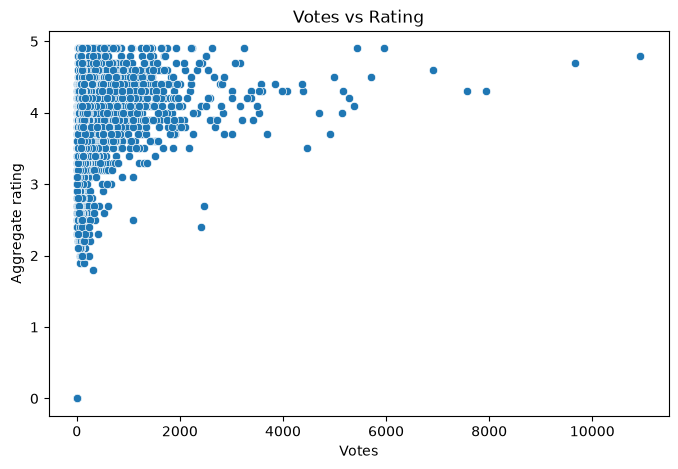

In [14]:
# Votes vs Rating
plt.figure(figsize=(8,5))
sns.scatterplot(x="Votes", y="Aggregate rating", data=df)
plt.title("Votes vs Rating")
plt.show()


The scatter plot suggests a positive relationship between the number of votes and restaurant ratings. Restaurants receiving more customer engagement tend to achieve higher ratings, although some exceptions are present.

### Interpretation
Investigates the relationship between customer votes and ratings.

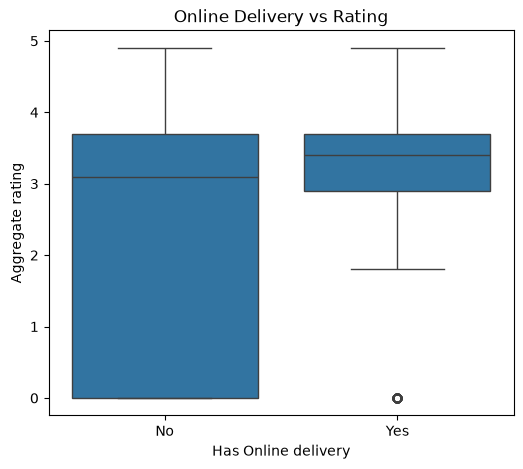

In [49]:
# Online Delivery vs Rating
plt.figure(figsize=(6,5))
sns.boxplot(x="Has Online delivery",
            y="Aggregate rating",
            data=df)
plt.title("Online Delivery vs Rating")
plt.show()


The comparison indicates that restaurants offering online delivery generally achieve competitive ratings. This suggests that providing delivery services may contribute to customer convenience and satisfaction.

### Interpretation
Compares ratings between restaurants with and without online delivery.

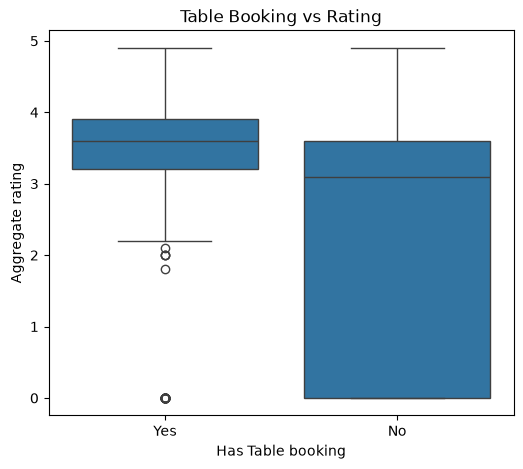

In [50]:
# Table Booking vs Rating
plt.figure(figsize=(6,5))
sns.boxplot(x="Has Table booking",
            y="Aggregate rating",
            data=df)
plt.title("Table Booking vs Rating")
plt.show()


The box plot shows differences in rating distributions between restaurants with and without table booking services. Restaurants offering reservations often exhibit higher median ratings, which may indicate a stronger focus on customer experience.

### Interpretation
Compares ratings between restaurants with and without table booking.

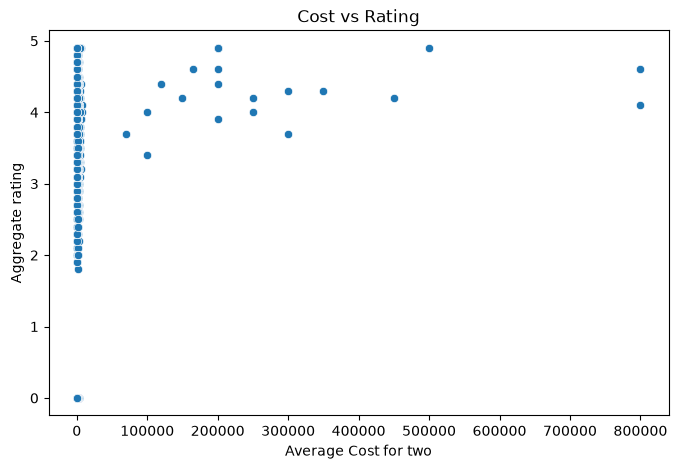

In [17]:
# Cost vs Rating
plt.figure(figsize=(8,5))
sns.scatterplot(x="Average Cost for two",
                y="Aggregate rating",
                data=df)
plt.title("Cost vs Rating")
plt.show()


The relationship between restaurant cost and rating appears relatively weak. While some expensive restaurants receive high ratings, higher prices do not necessarily guarantee better customer evaluations.

### Interpretation
Examines whether more expensive restaurants tend to have higher ratings.

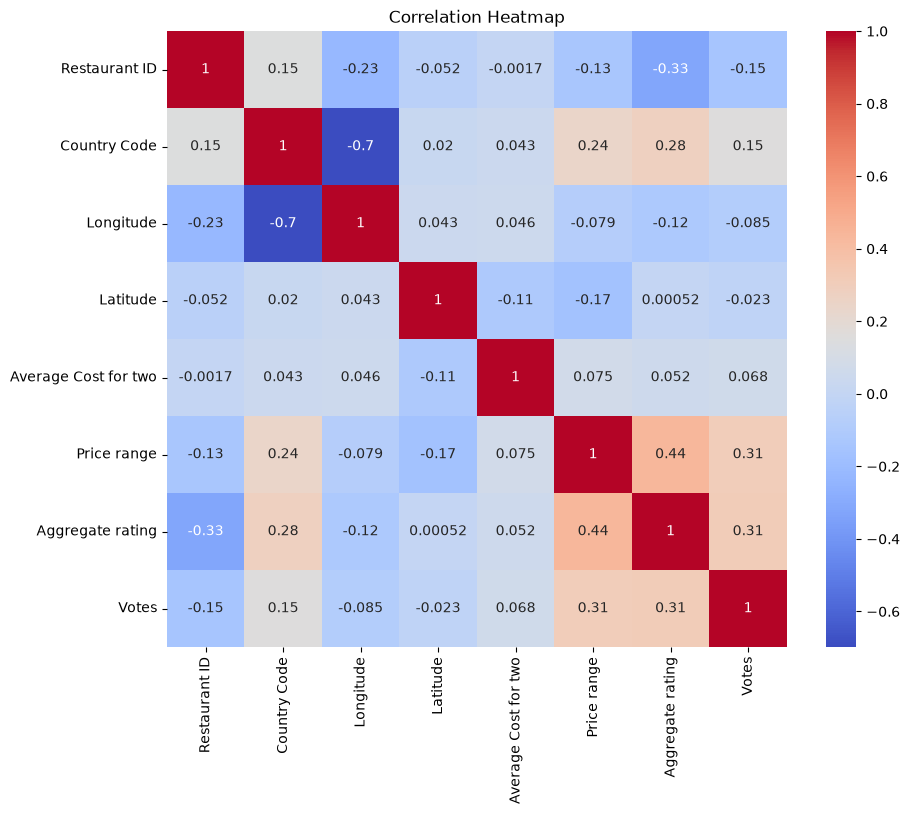

In [51]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()


The correlation matrix highlights the strength and direction of relationships among numerical variables. Most correlations are weak to moderate, indicating that restaurant performance is influenced by multiple factors rather than a single variable.

### Interpretation
Displays correlations among numerical variables. Correlation does not imply causation.

## F. Draw Conclusions

### Conclusions
This exploratory data analysis examined restaurant characteristics using the Zomato Restaurant Dataset. The analysis revealed that restaurant distribution is concentrated in a limited number of cities and that several cuisine categories dominate the dataset.

Most restaurants received moderate to high ratings, suggesting generally positive customer experiences. The results also indicated a positive association between customer votes and ratings, meaning that highly engaged restaurants often achieve better evaluations.

Online delivery and table booking services showed noticeable differences in rating distributions, suggesting that customer convenience may play a role in overall satisfaction. Additionally, the dataset contained several cost outliers representing premium restaurants.

The correlation analysis demonstrated that no single factor completely explains restaurant ratings, highlighting the importance of considering multiple variables when evaluating restaurant performance..

### Limitations
The study has several limitations. First, the dataset may not represent all restaurants equally across different cities and regions. Second, some variables contain missing information that required preprocessing. Third, correlation analysis identifies associations between variables but cannot establish causal relationships. Finally, customer preferences may be influenced by external factors that are not included in the dataset.